# 03 Feature Engineering and Baseline Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import display

ARTIFACT_DIR = Path.cwd() / "notebook_artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)


In [2]:
# Bereinigte Arbeitsbasis aus dem vorherigen Notebook laden

debitor_features_final = pd.read_pickle(ARTIFACT_DIR / "02_debitor_features_final.pkl")

print("Geladen:", ARTIFACT_DIR / "02_debitor_features_final.pkl")
print("Debitoren:", debitor_features_final.shape[0])
print("Features:", debitor_features_final.shape[1])

Geladen: c:\Users\jensm\Documents\data01-executive-search-analytics\notebooks\notebook_artifacts\02_debitor_features_final.pkl
Debitoren: 1361
Features: 28


## Baseline-Logik

Für die erste Cluster-Baseline wird bewusst **kein maximal breites Feature-Set** verwendet. Stattdessen wird eine schlankere Kernmatrix genutzt, um Redundanzen zwischen Aktivitäts-, Volumen- und Ratenmerkmalen zu reduzieren.

Leitidee der Baseline:
- Aktivität und Kundenbindung über wenige, klar interpretierbare Kennzahlen abbilden
- monetäre Größe und monetäre Intensität trennen
- Placement und Führungsanteil nicht mehrfach über Count, Rate und Zeitintensität gleichzeitig abbilden
- Diversitätsmerkmale zunächst dokumentieren, aber nicht automatisch in die Baseline zwingen

Die Baseline ist damit als **bewusst konservative Referenzlösung** zu verstehen. Erweiterte Features können später in Robustheits- und Sensitivitätsanalysen geprüft werden.

In [3]:
# Arbeitsbasis für die Baseline-Modellierung vorbereiten

baseline_df = debitor_features_final.copy()

print("Ausgangsbasis für die Baseline-Modellierung:")
print(f"Debitoren: {baseline_df.shape[0]}")
print(f"Features: {baseline_df.shape[1]}")

Ausgangsbasis für die Baseline-Modellierung:
Debitoren: 1361
Features: 28


In [4]:
# Numerische Kernfeatures für die Baseline festlegen

baseline_feature_candidates = [
    "invoice_count",
    "active_years_count",
    "recency_days",
    "net_index_sum",
    "net_per_invoice",
    "placement_count",
    "placement_rate",
    "leadership_rate"
]

optional_feature_candidates = [
    "invoices_per_active_year",
    "net_per_active_year",
    "nk_index_sum",
    "contract_type_nunique",
    "revenue_subtype_nunique",
    "job_category_nunique",
    "industry_nunique"
]

excluded_redundant_candidates = [
    "active_days",
    "net_index_mean",
    "nk_index_mean",
    "leadership_count",
    "placements_per_active_year",
    "leadership_per_active_year"
]

baseline_feature_cols = [col for col in baseline_feature_candidates if col in baseline_df.columns]
available_optional_feature_cols = [col for col in optional_feature_candidates if col in baseline_df.columns]
available_excluded_feature_cols = [col for col in excluded_redundant_candidates if col in baseline_df.columns]

print("Verwendete Baseline-Features:")
print(baseline_feature_cols)
print()
print("Optional dokumentierte, aber nicht standardmäßig verwendete Features:")
print(available_optional_feature_cols)
print()
print("Bewusst vorerst ausgeschlossene Redundanzkandidaten:")
print(available_excluded_feature_cols)

Verwendete Baseline-Features:
['invoice_count', 'active_years_count', 'recency_days', 'net_index_sum', 'net_per_invoice', 'placement_count', 'placement_rate', 'leadership_rate']

Optional dokumentierte, aber nicht standardmäßig verwendete Features:
['invoices_per_active_year', 'net_per_active_year', 'nk_index_sum', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique']

Bewusst vorerst ausgeschlossene Redundanzkandidaten:
['active_days', 'net_index_mean', 'nk_index_mean', 'leadership_count', 'placements_per_active_year', 'leadership_per_active_year']


In [5]:
# Erste Baseline-Feature-Matrix erzeugen

X_baseline_raw = baseline_df[baseline_feature_cols].copy()

print("Form der Baseline-Feature-Matrix:")
print(X_baseline_raw.shape)

X_baseline_raw.head()

Form der Baseline-Feature-Matrix:
(1361, 8)


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
0,101,16,34,5.974359,0.059152,30,0.29703,0.000000
1,1,1,2591,0.042735,0.042735,1,1.00000,0.000000
2,36,7,96,2.910427,0.080845,9,0.25000,0.333333
3,2,2,4668,0.153846,0.076923,1,0.50000,0.000000
4,4,1,5160,0.307692,0.076923,0,0.00000,0.000000


In [6]:
# Korrelationen innerhalb der Baseline grob prüfen

baseline_corr = X_baseline_raw.corr(numeric_only=True).round(3)
baseline_corr

,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
invoice_count,1.000,0.755,-0.190,0.957,-0.074,0.931,0.062,-0.086
active_years_count,0.755,1.000,-0.242,0.751,-0.062,0.727,0.111,-0.111
recency_days,-0.190,-0.242,1.000,-0.240,-0.228,-0.151,0.069,-0.501
net_index_sum,0.957,0.751,-0.240,1.000,0.080,0.936,0.127,-0.033
net_per_invoice,-0.074,-0.062,-0.228,0.080,1.000,-0.007,0.432,0.290
placement_count,0.931,0.727,-0.151,0.936,-0.007,1.000,0.213,-0.114
placement_rate,0.062,0.111,0.069,0.127,0.432,0.213,1.000,-0.098
leadership_rate,-0.086,-0.111,-0.501,-0.033,0.290,-0.114,-0.098,1.000


In [7]:
# Fehlwerte in der Baseline-Feature-Matrix prüfen

missing_baseline = pd.DataFrame({
    "missing_count": X_baseline_raw.isna().sum(),
    "missing_pct": (X_baseline_raw.isna().sum() / len(X_baseline_raw) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_baseline[missing_baseline["missing_count"] > 0]

,missing_count,missing_pct


In [8]:
# Fehlende numerische Werte für die Baseline pragmatisch behandeln

X_baseline_prepared = X_baseline_raw.copy()

for col in X_baseline_prepared.columns:
    if X_baseline_prepared[col].isna().sum() > 0:
        median_value = X_baseline_prepared[col].median()
        X_baseline_prepared[col] = X_baseline_prepared[col].fillna(median_value)

print("Fehlende Werte wurden für die Baseline mit dem Median gefüllt.")

Fehlende Werte wurden für die Baseline mit dem Median gefüllt.


In [9]:
# Baseline-Matrix nach der Imputation erneut prüfen

missing_baseline_after = pd.DataFrame({
    "missing_count": X_baseline_prepared.isna().sum(),
    "missing_pct": (X_baseline_prepared.isna().sum() / len(X_baseline_prepared) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_baseline_after[missing_baseline_after["missing_count"] > 0]

,missing_count,missing_pct


In [10]:
# Baseline-Matrix standardisieren

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_baseline_scaled = pd.DataFrame(
    scaler.fit_transform(X_baseline_prepared),
    columns=X_baseline_prepared.columns,
    index=X_baseline_prepared.index
)

print("Standardisierte Baseline-Matrix erstellt.")
print(X_baseline_scaled.shape)

X_baseline_scaled.head()

Standardisierte Baseline-Matrix erstellt.
(1361, 8)


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
0,4.342639,7.015599,-1.230390,3.235321,-0.576122,4.615278,0.321770,-0.686660
1,-0.489616,-0.714510,0.301183,-0.561413,-0.883097,-0.314371,3.748040,-0.686660
2,1.201673,2.377534,-1.193253,1.274149,-0.170492,1.045532,0.092548,0.194965
3,-0.441294,-0.199169,1.545249,-0.490293,-0.243830,-0.314371,1.311045,-0.686660
4,-0.344649,-0.714510,1.839943,-0.391818,-0.243830,-0.484359,-1.125950,-0.686660


In [11]:
# Standardisierung grob prüfen

scaling_check = pd.DataFrame({
    "mean_after_scaling": X_baseline_scaled.mean().round(4),
    "std_after_scaling": X_baseline_scaled.std().round(4)
})

scaling_check.head(10)

,mean_after_scaling,std_after_scaling
invoice_count,-0.0,1.0004
active_years_count,0.0,1.0004
recency_days,-0.0,1.0004
net_index_sum,0.0,1.0004
net_per_invoice,-0.0,1.0004
placement_count,-0.0,1.0004
placement_rate,0.0,1.0004
leadership_rate,-0.0,1.0004


In [12]:
# Eingesetzte Baseline-Features dokumentieren

baseline_feature_overview = pd.DataFrame({
    "feature": baseline_feature_cols
})

baseline_feature_overview

,feature
0,invoice_count
1,active_years_count
2,recency_days
3,net_index_sum
4,net_per_invoice
5,placement_count
6,placement_rate
7,leadership_rate


## Methodische Notiz zur Baseline

- Für die erste Baseline wurden bewusst nur wenige numerische Kernfeatures verwendet.
- Ziel ist eine robuste Referenzlösung mit geringerer Redundanz zwischen Aktivitäts-, Volumen- und Ratenmerkmalen.
- Dominante kategoriale Felder und Diversitätsmerkmale bleiben zunächst dokumentiert, werden aber nicht automatisch in die Baseline aufgenommen.
- Fehlende Werte in numerischen Baseline-Features wurden pragmatisch mit dem Median behandelt.
- Die standardisierte Baseline-Matrix bildet die Grundlage für eine erste metrisch nachvollziehbare Clusteranalyse.

In [13]:
# Arbeitsbasis für das Clustering vorbereiten

clustering_df = debitor_features_final.copy()

print("Ausgangsbasis für das Clustering:")
print(f"Debitoren: {clustering_df.shape[0]}")
print(f"Features: {clustering_df.shape[1]}")
print(f"Baseline-Matrix: {X_baseline_scaled.shape}")

Ausgangsbasis für das Clustering:
Debitoren: 1361
Features: 28
Baseline-Matrix: (1361, 8)


In [14]:
# K-Means für erste Clusterläufe vorbereiten

from sklearn.cluster import KMeans

In [15]:
# Erste K-Means-Läufe für verschiedene Clusterzahlen durchführen

k_values = range(2, 9)

kmeans_runs = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_baseline_scaled)
    
    kmeans_runs.append({
        "k": k,
        "inertia": kmeans.inertia_
    })

kmeans_runs_df = pd.DataFrame(kmeans_runs)
kmeans_runs_df

,k,inertia
0,2,7954.806527
1,3,6307.563458
2,4,5176.927702
3,5,4429.841005
4,6,3890.991979
5,7,3471.945570
6,8,3112.743268


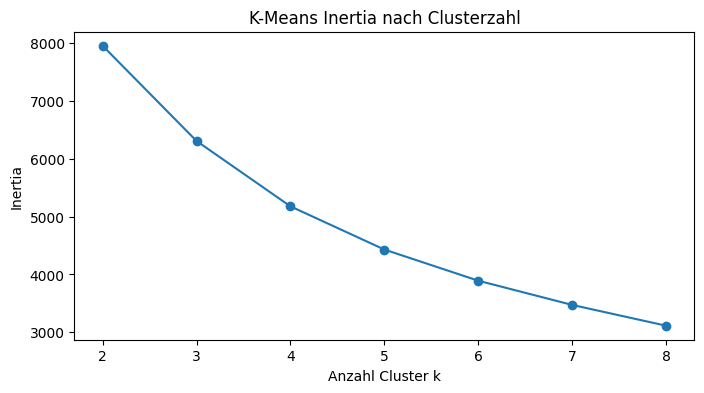

In [16]:
# Inertia für verschiedene Clusterzahlen visualisieren

plt.figure(figsize=(8, 4))
plt.plot(kmeans_runs_df["k"], kmeans_runs_df["inertia"], marker="o")
plt.title("K-Means Inertia nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

In [17]:
# Referenz-Clusterzahl für die erste Hauptauswertung festlegen

k_selected = 2
k_exploratory = 4

print(f"Metrisch priorisierte Referenzlösung: k = {k_selected}")
print(f"Explorative Vergleichslösung für spätere fachliche Prüfung: k = {k_exploratory}")

Metrisch priorisierte Referenzlösung: k = 2
Explorative Vergleichslösung für spätere fachliche Prüfung: k = 4


In [18]:
# K-Means mit der gewählten Clusterzahl ausführen

kmeans_final = KMeans(n_clusters=k_selected, random_state=42, n_init=10)
cluster_labels_final = kmeans_final.fit_predict(X_baseline_scaled)

print("K-Means-Lauf abgeschlossen.")
print(f"Anzahl Cluster: {k_selected}")

K-Means-Lauf abgeschlossen.
Anzahl Cluster: 2


In [19]:
# Clusterlabels an die Debitorbasis anhängen

clustering_df["cluster_kmeans"] = cluster_labels_final

print("Clusterlabels wurden ergänzt.")
clustering_df[["cluster_kmeans"]].head()

Clusterlabels wurden ergänzt.


,cluster_kmeans
0,1
1,0
2,0
3,0
4,0


In [20]:
# Clustergrößen prüfen

cluster_sizes = clustering_df["cluster_kmeans"].value_counts().sort_index().to_frame("count")
cluster_sizes

,count
cluster_kmeans,
0,1293
1,68


In [21]:
# Erste numerische Clusterprofile berechnen

cluster_profile_means = clustering_df.groupby("cluster_kmeans")[baseline_feature_cols].mean().round(3)
cluster_profile_means

,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
cluster_kmeans,,,,,,,,
0,7.626,2.084,2150.462,0.649,0.090,1.859,0.228,0.265
1,77.809,8.147,903.647,6.067,0.085,21.676,0.292,0.148


In [22]:
# Clusterprofile auf standardisierter Basis berechnen

X_clustered_scaled = X_baseline_scaled.copy()
X_clustered_scaled["cluster_kmeans"] = cluster_labels_final

cluster_profile_scaled = X_clustered_scaled.groupby("cluster_kmeans").mean().round(3)
cluster_profile_scaled

,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
cluster_kmeans,,,,,,,,
0,-0.169,-0.156,0.037,-0.173,0.005,-0.168,-0.016,0.015
1,3.222,2.969,-0.709,3.295,-0.092,3.200,0.299,-0.294


In [23]:
# Clustering-Ergebnis als neue Arbeitsbasis festhalten

clustering_results_df = clustering_df.copy()

print("Clustering-Arbeitsbasis erstellt.")
print(f"Debitoren: {clustering_results_df.shape[0]}")
print(f"Features inkl. Clusterlabel: {clustering_results_df.shape[1]}")

Clustering-Arbeitsbasis erstellt.
Debitoren: 1361
Features inkl. Clusterlabel: 29


## PCA Projektion der K Means Cluster

Die folgenden Zellen reduzieren die standardisierte Baseline Matrix mit PCA auf zwei Hauptkomponenten und visualisieren die zuvor gefundenen K Means Cluster farblich getrennt.


Erklärte Varianz PC1: 45.37%
Erklärte Varianz PC2: 21.36%
Erklärte Varianz gesamt: 66.73%


c:\Users\jensm\Documents\data01-executive-search-analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


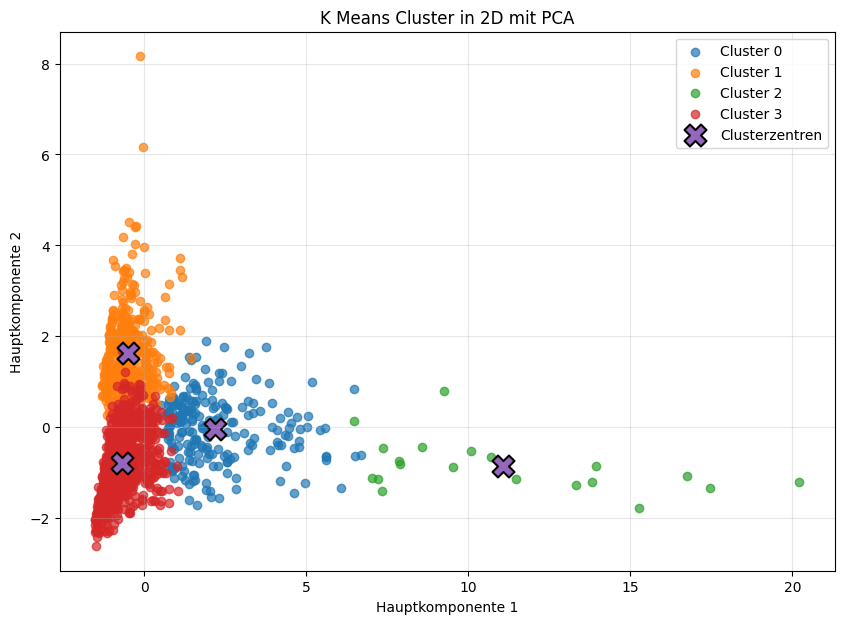

In [24]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# 1. K Means auf den ursprünglichen Daten
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_baseline_scaled)

# 2. PCA nur zur Reduktion für die Visualisierung
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_baseline_scaled)

# 3. DataFrame für Plot
plot_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X_baseline_scaled.index
)

plot_df["cluster"] = cluster_labels

# Optional: Clusterzentren ebenfalls in PCA Raum projizieren
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Erklärte Varianz
explained_variance = pca.explained_variance_ratio_
print(f"Erklärte Varianz PC1: {explained_variance[0]:.2%}")
print(f"Erklärte Varianz PC2: {explained_variance[1]:.2%}")
print(f"Erklärte Varianz gesamt: {explained_variance.sum():.2%}")

# Plot
plt.figure(figsize=(10, 7))

for cluster_id in sorted(plot_df["cluster"].unique()):
    cluster_data = plot_df[plot_df["cluster"] == cluster_id]
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

# Zentren einzeichnen
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    marker="X",
    edgecolor="black",
    linewidth=1.5,
    label="Clusterzentren"
)

plt.title("K Means Cluster in 2D mit PCA")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Erklärte Varianz PC1: 45.37%
Erklärte Varianz PC2: 21.36%
Erklärte Varianz gesamt: 66.73%


c:\Users\jensm\Documents\data01-executive-search-analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


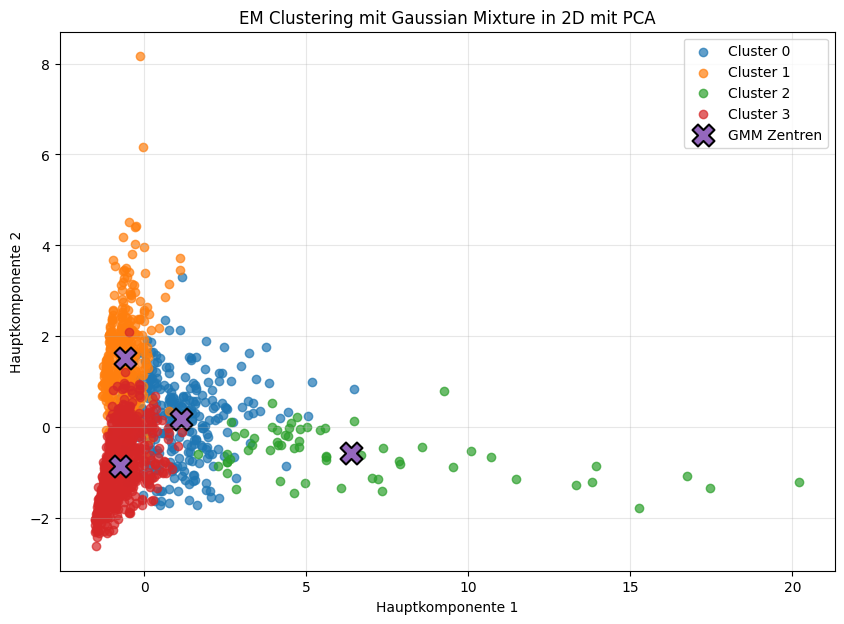

In [25]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. EM Clustering auf den ursprünglichen Daten
gmm = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42
)

gmm.fit(X_baseline_scaled)

# Harte Clusterzuordnung
cluster_labels = gmm.predict(X_baseline_scaled)

# Wahrscheinlichkeiten pro Cluster
cluster_probabilities = gmm.predict_proba(X_baseline_scaled)

# 2. PCA nur zur Reduktion für die Visualisierung
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_baseline_scaled)

# 3. DataFrame für Plot
plot_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X_baseline_scaled.index
)

plot_df["cluster"] = cluster_labels

# Mittelwerte der GMM Komponenten in PCA Raum projizieren
means_pca = pca.transform(gmm.means_)

# Erklärte Varianz
explained_variance = pca.explained_variance_ratio_
print(f"Erklärte Varianz PC1: {explained_variance[0]:.2%}")
print(f"Erklärte Varianz PC2: {explained_variance[1]:.2%}")
print(f"Erklärte Varianz gesamt: {explained_variance.sum():.2%}")

# Plot
plt.figure(figsize=(10, 7))

for cluster_id in sorted(plot_df["cluster"].unique()):
    cluster_data = plot_df[plot_df["cluster"] == cluster_id]
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

# Zentren der GMM Komponenten einzeichnen
plt.scatter(
    means_pca[:, 0],
    means_pca[:, 1],
    s=250,
    marker="X",
    edgecolor="black",
    linewidth=1.5,
    label="GMM Zentren"
)

plt.title("EM Clustering mit Gaussian Mixture in 2D mit PCA")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Methodische Notiz zur Clusterwahl

- Als erstes Clusterverfahren wurde K-Means als Baseline gewählt.
- Die Clusterbildung basiert auf der standardisierten numerischen Baseline-Matrix.
- Mehrere Clusterzahlen wurden zunächst explorativ über die Inertia verglichen.
- Für die erste Hauptauswertung wird die metrisch stärkere Referenzlösung priorisiert.
- Eine feinere Segmentierung kann ergänzend als explorative Arbeitslösung geprüft werden.
- Die formale Bewertung der Clusterqualität folgt im nächsten Schritt.

### Methodische Notiz zu PCA und EM

Die PCA wurde ergänzend eingesetzt, um die standardisierte Feature Matrix auf zwei Dimensionen zu projizieren und damit eine visuelle Darstellung der Clusterstruktur zu ermöglichen. Sie dient in diesem Notebook ausschließlich der grafischen Exploration und Interpretation der Daten. Die eigentliche Clusterbildung erfolgt weiterhin im ursprünglichen standardisierten Merkmalsraum.

Zusätzlich wurde ein EM Clustering mit einem Gaussian Mixture Model durchgeführt. Dieses Verfahren ergänzt die distanzbasierte K Means Baseline um eine probabilistische Perspektive, da es neben einer harten Zuordnung auch Zugehörigkeitswahrscheinlichkeiten zu mehreren Clustern abbilden kann. PCA und EM sind daher als ergänzende Analysebausteine und nicht als Ersatz der Baseline Methode zu verstehen.

In [26]:
# Clustering-Artefakte für das nächste Notebook speichern

baseline_clustering_artifacts = {
    "debitor_features_final": debitor_features_final,
    "baseline_feature_cols": baseline_feature_cols,
    "X_baseline_scaled": X_baseline_scaled,
    "k_selected": k_selected,
    "clustering_results_df": clustering_results_df
}

with open(ARTIFACT_DIR / "03_baseline_clustering_artifacts.pkl", "wb") as f:
    pickle.dump(baseline_clustering_artifacts, f)

print("Gespeichert:", ARTIFACT_DIR / "03_baseline_clustering_artifacts.pkl")

Gespeichert: c:\Users\jensm\Documents\data01-executive-search-analytics\notebooks\notebook_artifacts\03_baseline_clustering_artifacts.pkl
